# Tarea 2

#### Instrucciones:
- La tarea consta de una parte de preguntas y otra de desarrollo de código. Debe entregar todas las respuestas en formato notebook, y cuando la respuesta sea texto, debe hacer en celdas markdown con formato.
- La entrega de la Tarea es el día **17 de Octubre, 23:59 hrs.**


## Nombres:
- Miyaray Arenas Trejo
- Isidora Morales González

## Bosón de Higgs

En esta tarea trabajaremos con datos simulados del bosón de Higgs (versión simplificada), del desafío de [Kaggle](https://www.kaggle.com/c/higgs-boson/overview). Los archivos son Higgs_features.csv y Higgs_labels.csv. Las etiquetas son 0 (no hay señal de Higgs) y 1 (señal de Higgs). Las features son similares a los vistos en el set que utilizamos en clases, tales como energía faltantes, energía, momentum, rapidez transversal y azimutal, etc. Puede encontrar más detalles [acá](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). Note que el set de datos para esta tarea es una versión simplificada.

### Parte 1: Descripción de los datos

Cargue los datos dataframes o arreglos de `numpy`, uno para features y otro para etiquetas

- Identifique cúantes instancias y características hay en el set de datos
- Haga un gráfico de la distribución (histograma) de cada feature en el set de datos, en un sólo gráfico. Agregue una leyenda con las etiquetas (Feature 1, Feature 2....etc.) y fije la transparencia de los histogramas (parámetro alpha) en 0.5 para que se noten mejor. ¿Observa algo inusual en la distribución de alguna de las features? Comente en el impacto de esto para su modelo
- ¿Está balanceadas las etiquetas del set del datos? ¿ Por qué esto es un problema? ¿Qué métrica nos conviene usar?




In [ ]:
#Conectamos el drive con el notebook para poder utilizar los archivos cargados

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importamos las diversas librerias que se utilizarán en el proyecto

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import GridSearchCV

In [ ]:
#Cargamos los archivos

features_hist = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea_2/Higgs_features.csv', header = None)
features = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea_2/Higgs_features.csv')
labels = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Tarea_2/Higgs_labels.csv').iloc[:,0]

In [ ]:
#Verificamos que se haya agregado el header con los features

features.head()

,Features 1,Features 2,Features 3,Features 4,Features 5,Features 6,Features 7,Features 8
0,393.335,79.460,308.879,4.095,1.403,-1.411,49.063,39.478
1,71.048,29.291,55.602,2.439,1.667,-1.412,22.926,9.486
2,141.450,87.017,72.091,1.472,4.714,1.233,23.591,69.754
3,156.539,39.797,127.933,4.017,1.279,-1.408,21.415,18.222
4,89.639,34.399,66.741,2.934,1.417,-1.377,26.459,8.257


El conjunto de datos contiene **25.000 instancias** que corresponden a eventos simulados del bosón de Higgs y **8 características** asociadas a cada evento, cada una de estas instancias representa un posible evento físico, descrito por variables que incluyen energía, momentum entre otros.

Además de esto contamos con una columna de **labels** que indica si el evento corresponde a una señal del bosón de Higgs (1) o a un evento sin Higgs(0).

In [ ]:
print("Dimensiones del set de datos:")
print(f"Número de instancias: {features.shape[0]}")
print(f"Número de características: {features.shape[1]}")
print(f"Número de instancias: {labels.shape[0]}")


Dimensiones del set de datos:
Número de instancias: 25000
Número de características: 8
Número de instancias: 24999


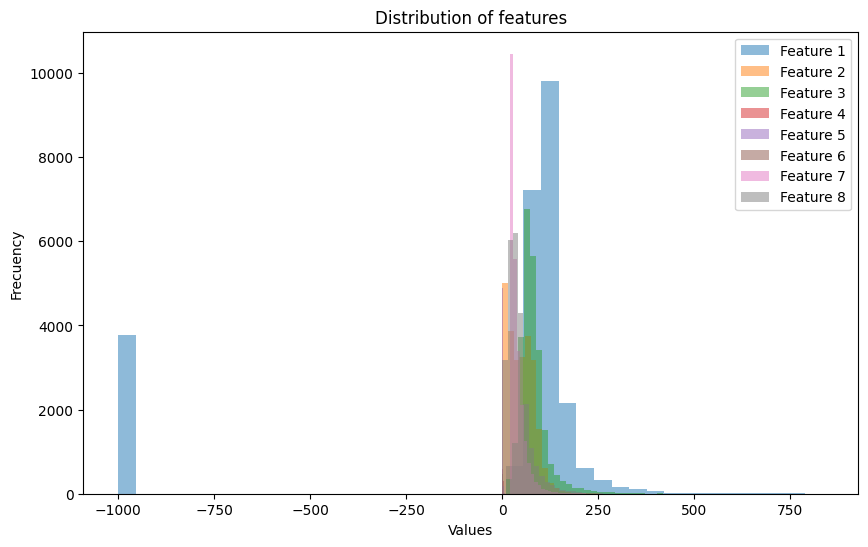

In [ ]:
#Generamos el histograma general con todos los features juntos para realizar el analisis
plt.subplots(figsize=(10,6))
for i in range(features.shape[1]):
    plt.hist(features.iloc[:, i], bins=40, alpha=0.5, label=f'Feature {i+1}')
plt.legend()
plt.xlabel('Values')
plt.ylabel('Frecuency')
plt.title('Distribution of features')
plt.show()

Es posible observar que en el gráfico se muestran los histográmas de las **8 features** del conjunto de datos del bosón de Higgs. Se observa que la distribución para las features entre 2 y 8 se encuentrana distribuidas en un rango positivi acotado entre los valores 0 y 250 app. Mientras que en el caso del **Feature 1**, esta presenta valores "atípicos" o "extremos" como se puede observar en el rango de valores negativos cercano a -1000.

Rapidamente podemos determinar que las escalas entre las features es muy diferente dado que la **feature 1** tiene valores que pueden llegar a magnitudes más grandes como 200 o -1000, mientras que la mayoría del resto de las features se concentran en valores pequeños o cercanos a cero.

Esta distribución puede impactar directamente en modelos que son sensibles a la escala como la **Regresión Logística, SMV o redes neuronales**, por lo tanto es recomendable normalizar el dataset antes de comenzar a entrenar el modelo, además si hay features con muchos ceros o valores con poca variabilidad estos pueden aportar poca información y sería conveniente realizar un **feature selection** para mejorar el rendimiento del modelo y evitar un overfitting.

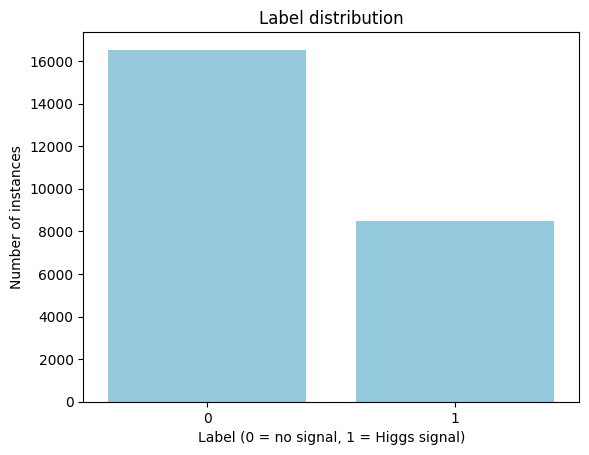

,proportion
0,
0,0.661026
1,0.338974


In [ ]:
#Realizamos el histograma donde es posible visibilizar la distribución de las etiquetas de los datos

sns.countplot(x=labels, color='skyblue')
plt.title("Label distribution")
plt.xlabel("Label (0 = no signal, 1 = Higgs signal)")
plt.ylabel("Number of instances")
plt.show()
labels.value_counts(normalize=True)


Como podemos observar la clase 0 donde no hay señal de Higgs es más abundante que la clase 1 donde sí hay señal de Higgs y esto nos dice que el data set está desbalanceado. Esto es un problema porque un modelo entrenado puede aprender directamente a predecir siempre la clase mayoritaria obteniendo así un atolo **accuracy** pero fallará en detectar los eventos "raros" , es decir la clase 1, que es justamente lo que necesitamos detectar con mayor precisión.

Para este caso vamos a utilizar la métrica **F1-score** que combina precision y recall y es útil en dataset desbalanceados.

### Parte 2: Árbol de decisión

- Implemente un clasificador de árbol de decisión con validación cruzada, para una métrica de su elección en base a lo respondido en la pregunta anterior. Reporte el promedio y desviación estándar de los scores obtenidos en los 5 folds.
- Para esta muestra en particular se recomienda usar `StratifiedKFold`. ¿Por qué?
- Genere las etiquetas predichas con `cross_val_predict` y genere la matriz de confusión
- A partir de la matriz de confusión indique los valores de TP, TN, FP, FN. ¿Qué error domina, FP o FN?

In [ ]:
# Para asegurarse de que tengan el mismo tamaño
min_len = min(len(features), len(labels))
features = features.iloc[:min_len, :]
labels = labels.iloc[:min_len]

print(f"Features: {features.shape}")
print(f"Labels: {labels.shape}")

Features: (24999, 8)
Labels: (24999,)


In [ ]:
# Árbol
tree_clf = DecisionTreeClassifier(random_state=101)

# Validación cruzada
cv_tree = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

# Scores métrica F1
scores = cross_val_score(tree_clf, features, labels, cv=cv_tree, scoring='f1')

print("Resultados de validación cruzada (árbol)")
print("F1 por fold:", np.round(scores, 4))
print(f"Promedio: {np.mean(scores):.4f}")
print(f"Desviación estándar: {np.std(scores):.4f}")

Resultados de validación cruzada (árbol)
F1 por fold: [0.343  0.3524 0.3527 0.3533 0.3489]
Promedio: 0.3501
Desviación estándar: 0.0039


Aquí conviene usar **StratifiedKFold** porque mantiene la proporción de clases en cada fold igual a la del dataset completo y esto es para evitar que algunos folds queden dominados por una sola clase y esto es lo que queremos evitar dado que los datos están desbalanceados y esto puede perjudicar el análisis.

In [ ]:
# Predicciones cruzadas
y_pred = cross_val_predict(tree_clf, features, labels, cv=cv_tree)

# Matriz de confusión
cm = confusion_matrix(labels, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"TP = {tp}, TN = {tn}, FP = {fp}, FN = {fn}")

TP = 3044, TN = 10653, FP = 5872, FN = 5430


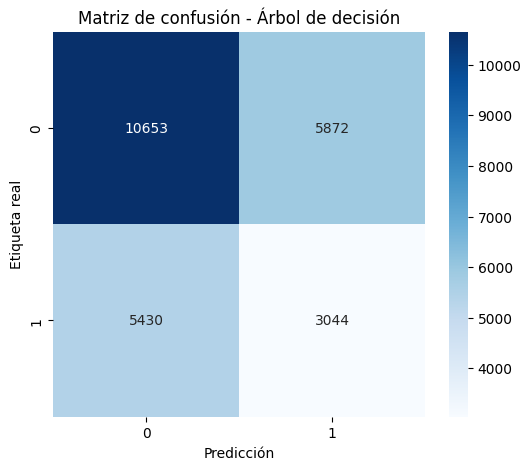

In [ ]:
# Visualización de la matriz de confusión

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión - Árbol de decisión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.show()

Ya obtenida la matriz de confusión nos interesa determinar qué error domina si FP o FN, estos se encuentran en la diagonal que va desde la parte superior derecha a la parte inferior izquierda donde los FP corresponden a **5872** y nos dice que esa cantidad de señales predichas no corresponden realmente a lo que estamos buscando mientras que los FN son **5430** casos donde no se predijo correctamente la señal de Higgs. EL modelo tiene un error FP que domina, es decir, detecta demasiados eventos que no son señal de Higgs pero los clasifica como tal.

### Parte 3: SVMs

- Ahora usemos un clasificador usando SVM. Usando SVC, deje los parámetros del clasificador los que viene por defecto y haga una validación cruzada con k=5 y reporte los scores, como hizo antes con el árbol de decisión. ¿Qué algoritmo tiene mejor performance?
Nota: SVMs es un algoritmo lento y puede tomar tiempo este cálculo. Si toma demasiado tiempo, reduzca el número de folds (no menos de 3).
- Reporte la matriz de confusión para SVC. Hay algún cambio de los valores de FP y FN respecto al modelo de árbol de decisión?

In [ ]:
# SCV
svc_model = SVC()  # Normalización de los datos y entrenamiento

# Validación cruzada
cv_svc = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

# Scores métrica F1
scores_svc = cross_val_score(svc_model, features, labels, cv=cv_svc, scoring='f1')

print("Resultados de validación cruzada (SVC)")
print("F1 por fold:", np.round(scores_svc, 4))
print(f"Promedio: {np.mean(scores_svc):.4f}")
print(f"Desviación estándar: {np.std(scores_svc):.4f}")

Resultados de validación cruzada (SVC)
F1 por fold: [0.6754 0.6462 0.6643 0.6512 0.6795]
Promedio: 0.6633
Desviación estándar: 0.0130


Si realizamos una comparación entre estos resultados y los obtenidos con el método de Árbol de Decisión notamos que el SVM es ampliamente mejor, esto se ve reflejado en que el promedio pasó de **0.3501** a un promedio de **0.6633** indicando que corresponde a un método más efectivo para calibrar entre la precisión y el recall de la clase minoritaria.



In [ ]:
y_pred_svc = cross_val_predict(svc_model, features, labels, cv=cv_svc)

# Matriz de confusión
cm_svc = confusion_matrix(labels, y_pred_svc)
tn, fp, fn, tp = cm_svc.ravel()
print(f"TP = {tp}, TN = {tn}, FP = {fp}, FN = {fn}")

TP = 5172, TN = 14578, FP = 1947, FN = 3302


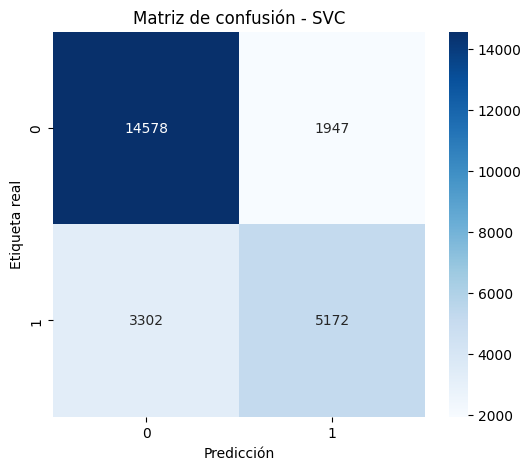

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión - SVC")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.show()

Podemos ver a simple vista que la cantidad de TP aumentó en comparación al método anterior y esto se traduce rápidamente a que los error de FN y FP disminuyeron tal como se ve en la matriz de confusión que ambos casos pasaron de 5430 a 3302 y de 5872 a 1947 respectivamente.

Esto también nos indica que el Árbol de Desición tiene un bajo desempeño en datasets desbalanceados y que no es capaz de capturar relaciones complejas entre los datos para tomar una mejor desición.


### Parte 4: optimización de hiperparámetros

- Intente optimizar los parámetros de SVC. Para evitar que tome demasiado tiempo, seleccione solo el primer 5% de los datos (asegúrese de desordenarlos antes)
- Haga un esquema de CV con GridSearch, con los siguientes valores de parámetros:
parameters = {'kernel':['linear','rbf'],'C':[1, 10, 100], 'gamma':[0.01, 0.1, 0.5], 'class_weight':[{1:1},{1:3},{1:5}]}
- Recuerde seguir usando la métrica que eligió más arriba.
- Esto tomará tiempo! Fije verbose=2 en GridSearch para monitorear el progreso, y njobs=4 o más para acelerar un poco el proceso.
- Reporte los parámetros y scores del mejor modelo



In [ ]:
#Selección del primer 5% de los datos

feat_des, lab_des = shuffle(features, labels, random_state=42)
porcentaje = int(0.05 * len(feat_des))
feat_subset, label_subset = feat_des.iloc[:porcentaje], lab_des.iloc[:porcentaje]

In [ ]:
#Optimización de los parámetros

parameters = {'svc__kernel': ['linear', 'rbf'],
    'svc__C': [1, 10, 100],
    'svc__gamma': [0.01, 0.1, 0.5],
    'svc__class_weight': [{1:1}, {1:3}, {1:5}]}

# Create a pipeline with StandardScaler and SVC
pipeline = make_pipeline(StandardScaler(), SVC())

# CV for all values of the parameters in the GridSearch
model = GridSearchCV(
    pipeline, # Use the pipeline as the estimator
    parameters,
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1', # Added scoring as per previous steps
    verbose = 2,
    n_jobs = 4,
)

model.fit(feat_subset, label_subset)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


Los mejores parámetros para el modelo son:

* kernel = 'linear'
* gamma = 0.01
* c = 10
* class_weight = {1:1}



### Parte 5: clases imbalanceadas
- Existen muchas estrategias para manejar clases imbalanceadas... (De hecho, en el paso anterior aplicamos una, puede decir cuál es?). Investigue o piense una solución para el desbalance, impleméntela para SVC con los parámetros optimizados, y comente su resultado, compare con el anterior

La estrategia aplicada en el paso anterior fue realizar un **ajuste de pesos de clase (class_weight)** cuando realizamos *GridSearch*. Lo que hace este ajuste es decirle al modelo que pese más en los errores, es decir, por ejemplo con class_weigth = {1:3} el modelo castiga 3 veces más por equivocarse en la clase 1 (señal de Higgs) que en la clase 0 (no Higgs), esto ayuda a reducir los falsos negativos y a aumentar el recall de la clase minoritaria.

Vamos a utilizar el parámetro **class_weight = 'balanced'** para realizar un ajuste automático de los pesos de cada clase en la función de costo del SVM, esto hace que el modelo considere más a la clase minoritaria sin la necesidad de crear datos sintéticos.

Se empleará **StandardScaler** para normalizar las features y así garantizar que todas las variables tengan la misma escala para evitar que aquellas con valores mayores dominen en la función de decisión del modelo.

La evaluación se realizará mediante validación cruzada estratificada que mantiene la proporción de clases en cada fold y seguiremos utilizando la métria **F1-score** que escogimos al inicio de los pasos.

A continuación vamos a realizar nuevamente una muestra desordenada de 5000 datos del dataset para poder realizar la comparación con el método anterior.

In [ ]:
#Selección del primer 5% de los datos

feat_des, lab_des = shuffle(features, labels, random_state=42)
features_subset = feat_des[:5000]
labels_subset = lab_des[:5000]

In [ ]:
# Pipeline: normalización + SVM con pesos balanceados
svc_model = make_pipeline(
    StandardScaler(),
    SVC(class_weight='balanced', kernel='rbf', C=10, gamma= 0.1)
)

# Validación cruzada estratificada
cv_svc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scores usando F1 (recomendado para desbalance leve)
scores_svc = cross_val_score(svc_model, features_subset, labels_subset, cv=cv_svc, scoring='f1')

print("Resultados de validación cruzada (SVC)")
print("F1 por fold:", np.round(scores_svc, 4))
print(f"Promedio: {np.mean(scores_svc):.4f}")
print(f"Desviación estándar: {np.std(scores_svc):.4f}")

Resultados de validación cruzada (SVC)
F1 por fold: [0.393  0.3598 0.4414 0.401  0.4093]
Promedio: 0.4009
Desviación estándar: 0.0263


Utilizando on los parámetros más optimos encontrados en la sección anterior y aplicando el nuevo parámetro **class_weight ='balanced'** obtuvimos los resultados anteriores donde podemos observar que la el promedio ahora es mayor con un valor de **0.07268** y una desviación estandar de **0.0190** demostrando así que que método es mejor.

### Parte 6: Conclusiones

- En base a sus resultados, cuál algoritmo de clasificación recomendaría para este problema?
- ¿Qué otras consideraciones o limitaciones tenemos?

#### Recomendaciones:

Al momento de elegir qué algoritmo es el más óptimo, debemos centrarnos en algo primordial y es el cómo está evaluando nuestros datos, es decir si es una buena medición. Esta verificación se realiza mediante la visualización de la matriz de confusión.
Para ambos casos, el del árbol de decisión y el SVC, es posible observar que logra identificar en su mayoría como verdaderos positivos los datos asignados al label 0. Mientras que en el label 1 es cuando se presentan las mayores dificultades.
Es aquí donde tenemos que centrarnos para evaluar qué proceso es mejor. Con los valores calculados anteriormente es posible deducir qué la mejor forma es mediante SCV, ya que minimiza en ambos casos los falsos positivos. Obteniendo de esta forma una clasificación más limpia con identificaciones verdaderas positivas para el caso del label 0 de 14578 y para el label 1 de 5172. Además podemos decir que no es un algoritmo que esté sobre ajustando los datos, puesto que la diagonal que nos entrega la matriz de confusión no corresponde al 100% de los datos. Esto en otras palabras, indica que aún es lo suficientemente general la clasificación para que existan falsos positivos y falsos negativos.

#### Limitaciones:

* El tiempo que se necesita para lograr un entrenamiento con SVM puede ser altamente costoso en datasets muy grandes, por eso en la últimas secciones tuvimos que trabajar con sub muestras de 5000 datos.

* En esta oportunidad el desbalance que había en nuestro dataset era aproximadamente de 63% v/s 34%, el método de SVM funciona para estos casos pero si la situación fuera diferente como 90% v/s 10% de desbalance, tendríamos que estudiar aplicar otras técnicas como SMOTE que corresponde a una técnica de sobre-muestreo sintético donde se crean nuevos datos de la clase minoritaria interpolando entre los vecinos más cercanos hasta lograr que las clases tengan la misma cantidad de datos sin perder información.

